В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [ ]:
raw_df = pd.read_csv(..., index_col=0)

train_df, val_df = train_test_split(...)

# Створюємо трен. і вал. набори
input_cols = ...
target_col = ...
train_inputs, train_targets = ...
val_inputs, val_targets = ...

# Виявляємо числові і категоріальні колонки
numeric_cols = ...
categorical_cols = ...

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', ...)
])

categorical_transformer = Pipeline(steps=[
    ('onehot', ...)
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', ...),
        ('cat', ...)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', ...),
    ('classifier', ...)
])

# Тренуємо пайплайн
....

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    roc_auc = ...
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")
    confusion_matrix_ = ...
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(...)
val_preds = predict_and_plot(...)

# Зберігаємо модель для подальшого використання
joblib.dump(...)


Mounted at /content/drive
Area under ROC score on Train dataset: 88.25%


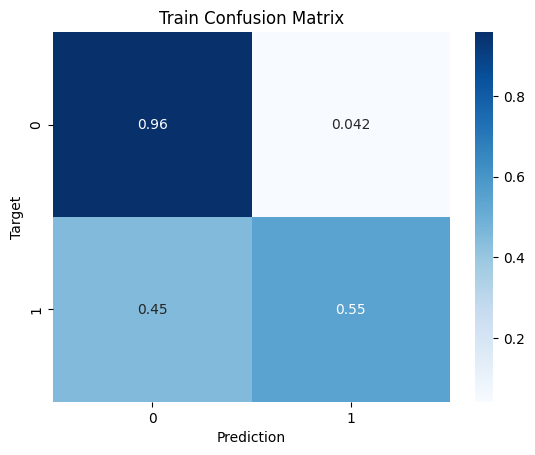

Area under ROC score on Validation dataset: 87.97%


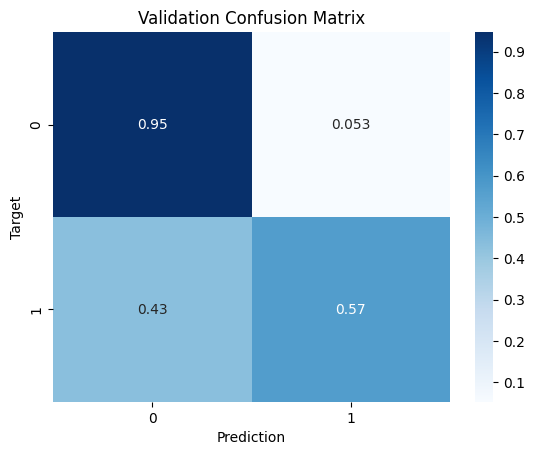

['log_reg_pipeline.joblib']

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix

from google.colab import drive
drive.mount('/content/drive')

data_dir = '/content/drive/MyDrive/ML1/data/kaggle_data'

# 1. Читання даних (id стає індексом)
raw_df = pd.read_csv(f'{data_dir}/train.csv', index_col=0)

# 2. Розбиття train/val
train_df, val_df = train_test_split(raw_df, test_size=0.2,
                                    stratify=raw_df['Exited'], random_state=42)

input_cols = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
              'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
              'EstimatedSalary']
target_col = 'Exited'
train_inputs, train_targets = train_df[input_cols], train_df[target_col]
val_inputs, val_targets = val_df[input_cols], val_df[target_col]

# 3. Числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include='number').columns.tolist()
categorical_cols = train_inputs.select_dtypes(include='object').columns.tolist()

# 4. Трансформери
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# 5. Пайплайн = препроцесинг + модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# 6. Тренування
model_pipeline.fit(train_inputs, train_targets)

# 7. Метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    probs = model_pipeline.predict_proba(inputs)[:, 1]   # для AUC - ймовірності!
    roc_auc = roc_auc_score(targets, probs) * 100
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction'); plt.ylabel('Target')
    plt.title(f'{name} Confusion Matrix')
    plt.show()
    return preds

train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')

# 8. Зберігаємо ВЕСЬ пайплайн (препроцесинг + модель разом)
joblib.dump(model_pipeline, 'log_reg_pipeline.joblib')

**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

Area under ROC score on Train (poly 2) dataset: 93.03%


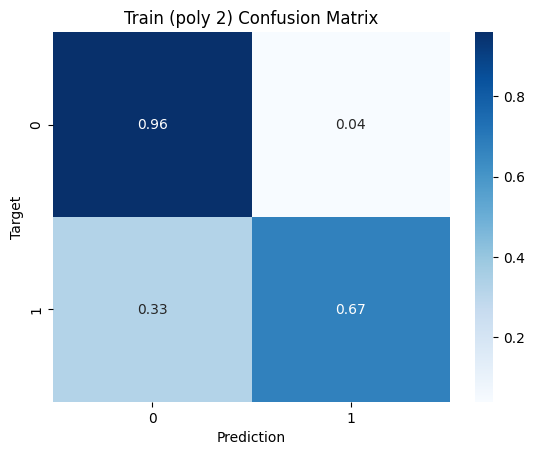

Area under ROC score on Validation (poly 2) dataset: 92.75%


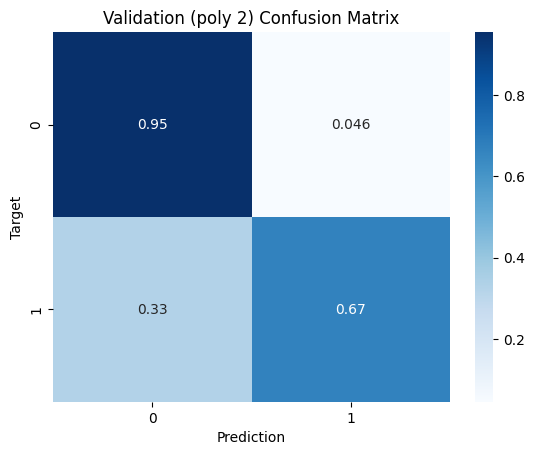

array([1., 0., 0., ..., 0., 0., 0.])

In [2]:
numeric_transformer_poly2 = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

preprocessor_poly2 = ColumnTransformer(transformers=[
    ('num', numeric_transformer_poly2, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

model_pipeline_poly2 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly2),
    ('classifier', LogisticRegression(solver='liblinear'))
])

model_pipeline_poly2.fit(train_inputs, train_targets)
predict_and_plot(model_pipeline_poly2, train_inputs, train_targets, 'Train (poly 2)')
predict_and_plot(model_pipeline_poly2, val_inputs, val_targets, 'Validation (poly 2)')

Використання поліному 2 степеня покращили модель AUROC зріс з 87.97% до 92.75%. Оверфіту моделі не видно.

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Area under ROC score on Train (poly 4) dataset: 93.94%


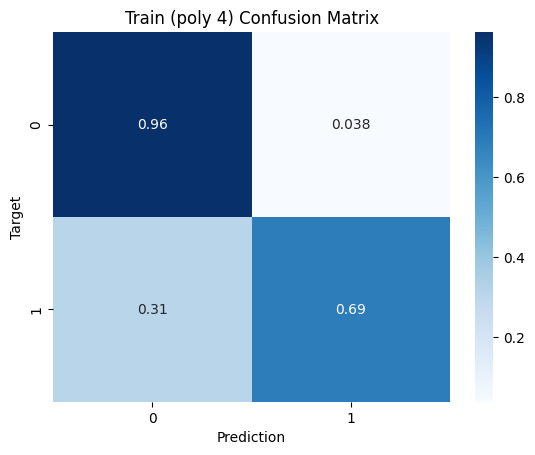

Area under ROC score on Validation (poly 4) dataset: 93.23%


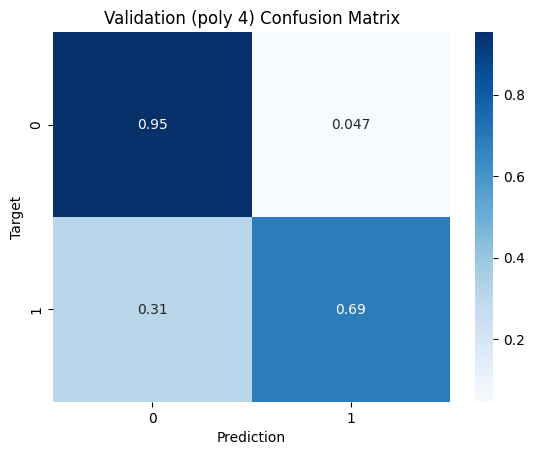

,id,Exited
0,15000,0.062242
1,15001,0.015432
2,15002,0.055664
3,15003,0.423002
4,15004,0.026680


In [4]:
numeric_transformer_poly4 = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=4, include_bias=False)),
    ('scaler', StandardScaler())
])

preprocessor_poly4 = ColumnTransformer(transformers=[
    ('num', numeric_transformer_poly4, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

model_pipeline_poly4 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly4),
    ('classifier', LogisticRegression(solver='liblinear'))
])

model_pipeline_poly4.fit(train_inputs, train_targets)
predict_and_plot(model_pipeline_poly4, train_inputs, train_targets, 'Train (poly 4)')
predict_and_plot(model_pipeline_poly4, val_inputs, val_targets, 'Validation (poly 4)')

# --- Submission найкращою моделлю ---
best_pipeline = model_pipeline_poly4

test_raw_df = pd.read_csv(f'{data_dir}/test.csv', index_col=0)
submission = pd.read_csv(f'{data_dir}/sample_submission.csv')
# пайплайн сам робить весь препроцесинг - подаємо сирі дані
submission['Exited'] = best_pipeline.predict_proba(test_raw_df[input_cols])[:, 1]
display(submission.head())
submission.to_csv(f'{data_dir}/submission_poly4.csv', index=False)

Модель з poly 4 ще трохи покращила результат AUROC 93.23% проти 92.75% у поліномі 2 ступеня. Перенавчання не спостерігається. Беру для каггл змагання поліном 4 ст.

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

reg_df = pd.read_csv('/content/drive/MyDrive/ML1/data/regression_data.csv')
reg_df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,-0.190339,-1.382800,-0.875618,0.538910,-1.037246,28.938854
1,-0.321386,-0.563725,0.412931,-0.147057,-0.825497,-7.664581
2,2.122156,-1.519370,1.032465,-1.260884,0.917862,-63.845482
3,-1.380101,-0.055548,-1.703382,0.074095,1.628616,4.076259
4,-0.072829,-1.514847,-0.846794,0.714000,0.473238,34.879013


In [18]:
X = reg_df.drop(columns='target')
y = reg_df['target']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y, test_size=0.2, random_state = 42)

lin_reg_poly5 = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=5, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
lin_reg_poly5.fit(X_train_r, y_train_r)

def eval_regression(pipe, name):
    print(f'{name}:  R2 train = {r2_score(y_train_r, pipe.predict(X_train_r)):.3f}'
          f'   R2 test = {r2_score(y_test_r, pipe.predict(X_test_r)):.3f}')

eval_regression(lin_reg_poly5, 'LinearRegression + poly 5')

LinearRegression + poly 5:  R2 train = 1.000   R2 test = 0.931


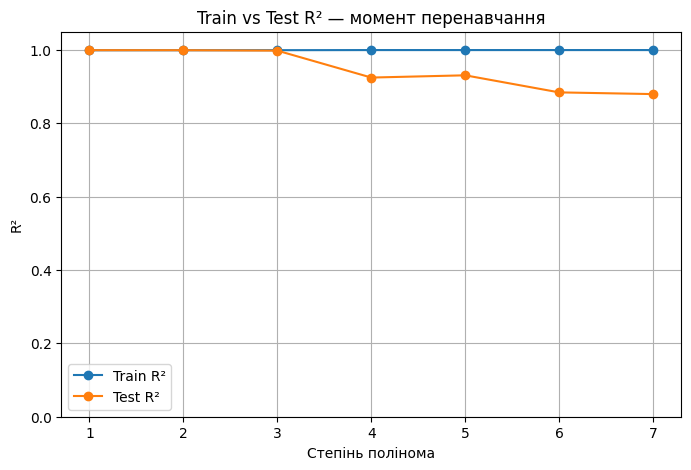

In [19]:
degrees = range(1, 8)
r2_train_list, r2_test_list = [], []

for d in degrees:
    pipe = Pipeline(steps=[
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ])
    pipe.fit(X_train_r, y_train_r)
    r2_train_list.append(r2_score(y_train_r, pipe.predict(X_train_r)))
    r2_test_list.append(r2_score(y_test_r, pipe.predict(X_test_r)))

plt.figure(figsize=(8, 5))
plt.plot(degrees, r2_train_list, 'o-', label='Train R²')
plt.plot(degrees, r2_test_list, 'o-', label='Test R²')
plt.xlabel('Степінь полінома')
plt.ylabel('R²')
plt.ylim(0, 1.05)
plt.title('Train vs Test R² — момент перенавчання')
plt.legend(); plt.grid(True)
plt.show()

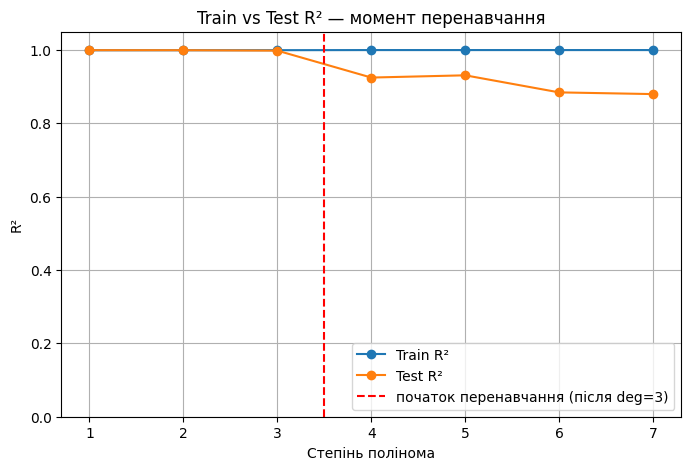

In [24]:

plt.figure(figsize=(8, 5))
plt.plot(degrees, r2_train_list, 'o-', label='Train R²')
plt.plot(degrees, r2_test_list, 'o-', label='Test R²')

# останній степінь, де test ще тримається близько до максимуму
threshold = max(r2_test_list) - 0.01
last_good = max(d for d, r2 in zip(degrees, r2_test_list) if r2 >= threshold)

plt.axvline(x=last_good + 0.5, color='red', linestyle='--',
            label=f'початок перенавчання (після deg={last_good})')

plt.xlabel('Степінь полінома')
plt.ylabel('R²')
plt.ylim(0, 1.05)
plt.title('Train vs Test R² — момент перенавчання')
plt.legend(); plt.grid(True)
plt.show()

До полінома третього ступеня модель добре прогнозує як для тренувального так і для тестового набору, потім тестовий набір отримує розбіжності і показує перенавчання. Модель з поліномом 5 ступеня перенавчена.

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [25]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet
import warnings
warnings.filterwarnings('ignore')

pipes = {}
for name, mdl in {'LinearRegression': LinearRegression(), 'Lasso': Lasso(),
                  'Ridge': Ridge(), 'ElasticNet': ElasticNet()}.items():
    pipe = Pipeline(steps=[
        ('poly', PolynomialFeatures(degree=20, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model', mdl)
    ])
    pipe.fit(X_train_r, y_train_r)
    eval_regression(pipe, f'{name} + poly 20')
    pipes[name] = pipe

# Аналіз: скільки коефіцієнтів реально використовується
for name in ['Lasso', 'Ridge', 'ElasticNet']:
    c = pipes[name].named_steps['model'].coef_.ravel()
    print(f'{name}: ненульових коефіцієнтів {(abs(c) > 1e-6).sum()} з {len(c)}')

# Що залишив Lasso
feat_names = pipes['Lasso'].named_steps['poly'].get_feature_names_out(X.columns)
c = pipes['Lasso'].named_steps['model'].coef_.ravel()
print('Топ-ознака Lasso:', feat_names[abs(c).argmax()])
print(reg_df.corr()['target'].round(3))

LinearRegression + poly 20:  R2 train = 1.000   R2 test = -0.833
Lasso + poly 20:  R2 train = 0.999   R2 test = 0.999
Ridge + poly 20:  R2 train = 0.999   R2 test = 0.669
ElasticNet + poly 20:  R2 train = 0.926   R2 test = 0.818
Lasso: ненульових коефіцієнтів 1 з 53129
Ridge: ненульових коефіцієнтів 53113 з 53129
ElasticNet: ненульових коефіцієнтів 130 з 53129
Топ-ознака Lasso: feature_4
feature_1    0.007
feature_2   -0.050
feature_3   -0.043
feature_4    1.000
feature_5   -0.155
target       1.000
Name: target, dtype: float64


feature_4 єдина ознака яка реально впливає на таргет. Звичайна лінійна регресія передбачає погано 83%. Лассо найкраща модель і прогнозує з результатом 99,9%.

Area under ROC score on Train (poly 4 + L1) dataset: 93.83%


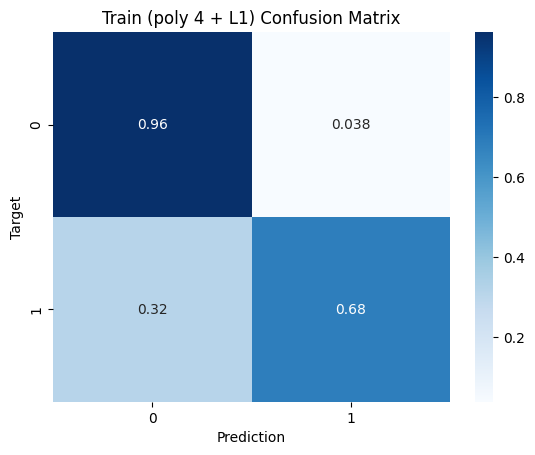

Area under ROC score on Validation (poly 4 + L1) dataset: 93.44%


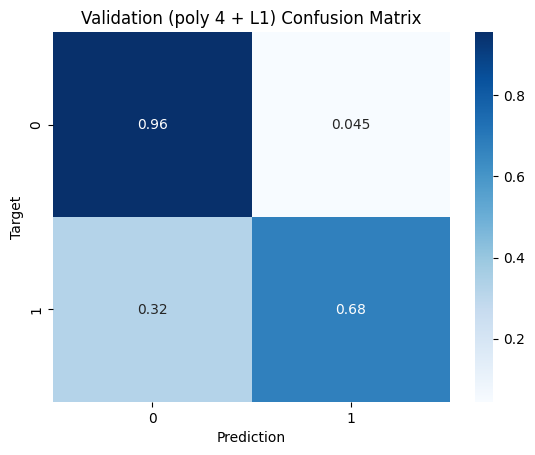

array([1., 0., 0., ..., 0., 0., 0.])

In [26]:
# Додатковий експеримент: лог регресія з L1-регуляризацією (як у Lasso)
model_pipeline_l1 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly4),          # препроцесинг poly 4
    ('classifier', LogisticRegression(penalty='l1', solver='liblinear', C=1.0))
])

model_pipeline_l1.fit(train_inputs, train_targets)

predict_and_plot(model_pipeline_l1, train_inputs, train_targets, 'Train (poly 4 + L1)')
predict_and_plot(model_pipeline_l1, val_inputs, val_targets, 'Validation (poly 4 + L1)')

In [27]:
# Submission файл для змагання з лассо
test_raw_df = pd.read_csv(f'{data_dir}/test.csv', index_col=0)
submission = pd.read_csv(f'{data_dir}/sample_submission.csv')
submission['Exited'] = model_pipeline_l1.predict_proba(test_raw_df[input_cols])[:, 1]
display(submission.head())
submission.to_csv(f'{data_dir}/submission_poly4_l1.csv', index=False)

,id,Exited
0,15000,0.071510
1,15001,0.013736
2,15002,0.058650
3,15003,0.431365
4,15004,0.024008
